<a href="https://colab.research.google.com/github/lhatabeh/ModelCounting/blob/main/RL_Autonomous_Decision_Making.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
class GridWorld:
    def __init__(self, size=6, obstacles=None):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        if obstacles is None:
            self.obstacles = [(1, 2), (2, 2), (3, 1), (4, 3)]
        else:
            self.obstacles = obstacles

        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state

        # actions: 0 = up, 1 = down, 2 = left, 3 = right
        if action == 0:
            x -= 1
        elif action == 1:
            x += 1
        elif action == 2:
            y -= 1
        elif action == 3:
            y += 1

        new_state = (x, y)

        # Check wall collision
        if x < 0 or x >= self.size or y < 0 or y >= self.size:
            new_state = self.state
            reward = -10
            done = False

        # Check obstacle collision
        elif new_state in self.obstacles:
            reward = -50
            done = True

        # Check goal
        elif new_state == self.goal:
            reward = 100
            done = True

        # Normal movement
        else:
            reward = -1
            done = False

        self.state = new_state
        return new_state, reward, done

    def render(self):
        grid = [["." for _ in range(self.size)] for _ in range(self.size)]

        for obs in self.obstacles:
            grid[obs[0]][obs[1]] = "X"

        grid[self.start[0]][self.start[1]] = "S"
        grid[self.goal[0]][self.goal[1]] = "G"

        x, y = self.state
        if self.state != self.start and self.state != self.goal:
            grid[x][y] = "A"

        for row in grid:
            print(" ".join(row))
        print()

In [ ]:
env = GridWorld()
env.render()

S . . . . .
. . X . . .
. . X . . .
. X . . . .
. . . X . .
. . . . . G



In [ ]:
class QLearningAgent:
    def __init__(self, env, learning_rate=0.1, discount_factor=0.9, epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01):
        self.env = env
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

        # Q-table: one value for each state and action
        self.q_table = np.zeros((env.size, env.size, 4))

    def choose_action(self, state):
        x, y = state

        # Exploration
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, 3)

        # Exploitation
        return np.argmax(self.q_table[x, y])

    def update(self, state, action, reward, next_state):
        x, y = state
        nx, ny = next_state

        old_value = self.q_table[x, y, action]
        next_max = np.max(self.q_table[nx, ny])

        new_value = old_value + self.lr * (reward + self.gamma * next_max - old_value)
        self.q_table[x, y, action] = new_value

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

In [ ]:
def train_q_learning(env, episodes=1000, max_steps=100):
    agent = QLearningAgent(env)

    rewards_per_episode = []
    steps_per_episode = []
    success_count = 0
    collision_count = 0

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            action = agent.choose_action(state)
            next_state, reward, done = env.step(action)

            agent.update(state, action, reward, next_state)

            state = next_state
            total_reward += reward
            steps += 1

            if done:
                if state == env.goal:
                    success_count += 1
                else:
                    collision_count += 1
                break

        agent.decay_epsilon()

        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)

    results = {
        "agent": agent,
        "rewards": rewards_per_episode,
        "steps": steps_per_episode,
        "success_rate": success_count / episodes,
        "collision_rate": collision_count / episodes
    }

    return results

In [ ]:
env = GridWorld()
q_results = train_q_learning(env, episodes=1000)

print("Q-Learning Success Rate:", q_results["success_rate"])
print("Q-Learning Collision Rate:", q_results["collision_rate"])

Q-Learning Success Rate: 0.785
Q-Learning Collision Rate: 0.215


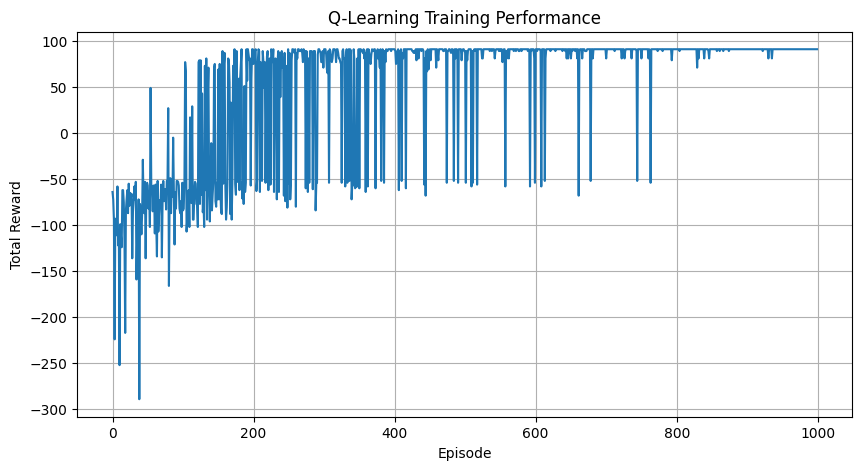

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(q_results["rewards"])
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Training Performance")
plt.grid(True)
plt.show()

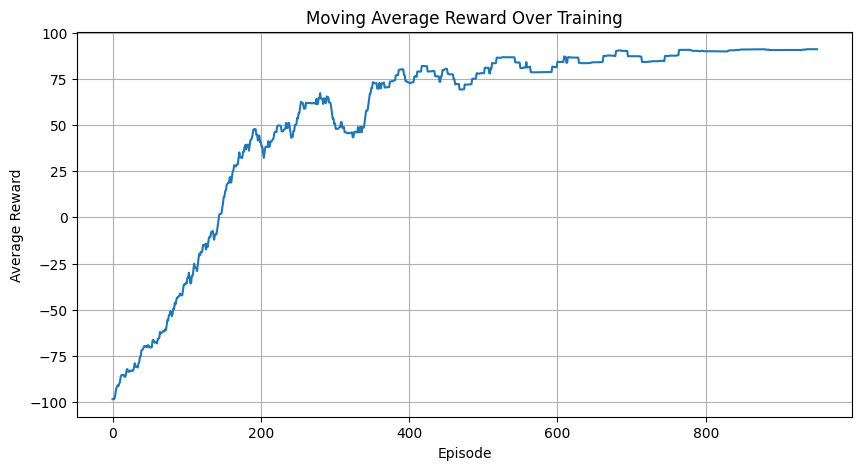

In [ ]:
window = 50
moving_avg = np.convolve(q_results["rewards"], np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_avg)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Moving Average Reward Over Training")
plt.grid(True)
plt.show()

In [ ]:
def rule_based_agent(env, episodes=100, max_steps=100):
    success_count = 0
    collision_count = 0
    rewards = []
    steps_list = []

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            x, y = state
            gx, gy = env.goal

            possible_actions = []

            # Prefer moving toward the goal
            if gx > x:
                possible_actions.append(1)  # down
            if gy > y:
                possible_actions.append(3)  # right
            if gx < x:
                possible_actions.append(0)  # up
            if gy < y:
                possible_actions.append(2)  # left

            if not possible_actions:
                action = random.randint(0, 3)
            else:
                action = random.choice(possible_actions)

            next_state, reward, done = env.step(action)

            state = next_state
            total_reward += reward
            steps += 1

            if done:
                if state == env.goal:
                    success_count += 1
                else:
                    collision_count += 1
                break

        rewards.append(total_reward)
        steps_list.append(steps)

    results = {
        "rewards": rewards,
        "steps": steps_list,
        "success_rate": success_count / episodes,
        "collision_rate": collision_count / episodes
    }

    return results

In [ ]:
env = GridWorld()
rule_results = rule_based_agent(env, episodes=100)

print("Rule-Based Success Rate:", rule_results["success_rate"])
print("Rule-Based Collision Rate:", rule_results["collision_rate"])

Rule-Based Success Rate: 0.18
Rule-Based Collision Rate: 0.82


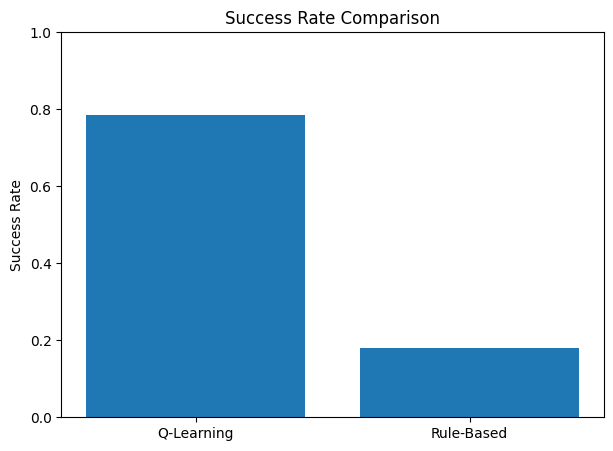

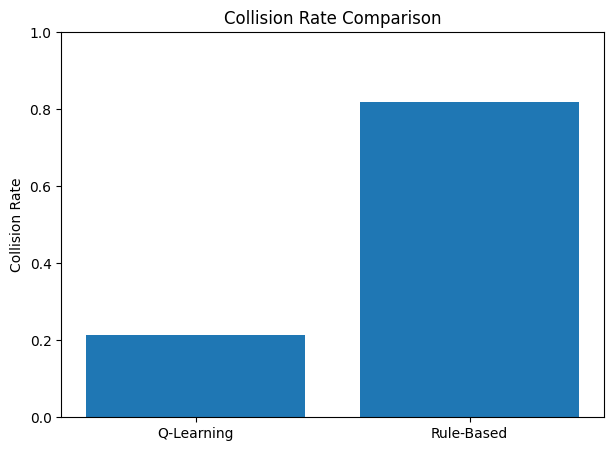

In [ ]:
labels = ["Q-Learning", "Rule-Based"]
success_rates = [q_results["success_rate"], rule_results["success_rate"]]
collision_rates = [q_results["collision_rate"], rule_results["collision_rate"]]

plt.figure(figsize=(7, 5))
plt.bar(labels, success_rates)
plt.ylabel("Success Rate")
plt.title("Success Rate Comparison")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7, 5))
plt.bar(labels, collision_rates)
plt.ylabel("Collision Rate")
plt.title("Collision Rate Comparison")
plt.ylim(0, 1)
plt.show()

In [ ]:
dynamic_obstacles = [(1, 1), (2, 3), (3, 3), (4, 2)]
dynamic_env = GridWorld(size=6, obstacles=dynamic_obstacles)

dynamic_env.render()

S . . . . .
. X . . . .
. . . X . .
. . . X . .
. . X . . .
. . . . . G



In [ ]:
def evaluate_trained_agent(agent, env, episodes=100, max_steps=100):
    success_count = 0
    collision_count = 0
    rewards = []
    steps_list = []

    old_env = agent.env
    agent.env = env

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        steps = 0

        for step in range(max_steps):
            x, y = state
            action = np.argmax(agent.q_table[x, y])

            next_state, reward, done = env.step(action)

            state = next_state
            total_reward += reward
            steps += 1

            if done:
                if state == env.goal:
                    success_count += 1
                else:
                    collision_count += 1
                break

        rewards.append(total_reward)
        steps_list.append(steps)

    agent.env = old_env

    return {
        "success_rate": success_count / episodes,
        "collision_rate": collision_count / episodes,
        "average_reward": np.mean(rewards),
        "average_steps": np.mean(steps_list)
    }

In [ ]:
dynamic_q_results = evaluate_trained_agent(q_results["agent"], dynamic_env)

print(dynamic_q_results)

{'success_rate': 1.0, 'collision_rate': 0.0, 'average_reward': np.float64(91.0), 'average_steps': np.float64(10.0)}


In [ ]:
results_table = {
    "Method": ["Q-Learning Static", "Rule-Based Static", "Q-Learning Dynamic"],
    "Success Rate": [
        q_results["success_rate"],
        rule_results["success_rate"],
        dynamic_q_results["success_rate"]
    ],
    "Collision Rate": [
        q_results["collision_rate"],
        rule_results["collision_rate"],
        dynamic_q_results["collision_rate"]
    ],
    "Average Reward": [
        np.mean(q_results["rewards"]),
        np.mean(rule_results["rewards"]),
        dynamic_q_results["average_reward"]
    ],
    "Average Steps": [
        np.mean(q_results["steps"]),
        np.mean(rule_results["steps"]),
        dynamic_q_results["average_steps"]
    ]
}

import pandas as pd
df = pd.DataFrame(results_table)
df

,Method,Success Rate,Collision Rate,Average Reward,Average Steps
0,Q-Learning Static,0.785,0.215,51.975,11.402
1,Rule-Based Static,0.180,0.820,-26.740,4.740
2,Q-Learning Dynamic,1.000,0.000,91.000,10.000


### Comparison of Agent Performances

Let's visualize the key performance metrics for each agent: Success Rate, Collision Rate, Average Reward, and Average Steps.

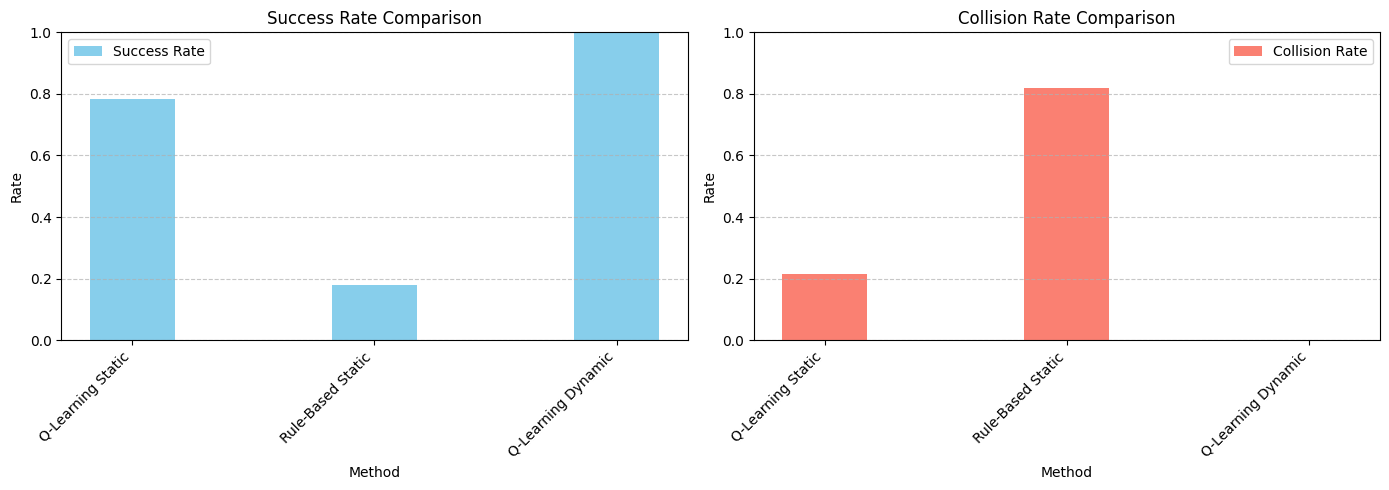

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Success Rate
bar_width = 0.35
index = np.arange(len(df['Method']))

axes[0].bar(index, df['Success Rate'], bar_width, label='Success Rate', color='skyblue')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Rate')
axes[0].set_title('Success Rate Comparison')
axes[0].set_xticks(index)
axes[0].set_xticklabels(df['Method'], rotation=45, ha='right')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Collision Rate
axes[1].bar(index, df['Collision Rate'], bar_width, label='Collision Rate', color='salmon')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Rate')
axes[1].set_title('Collision Rate Comparison')
axes[1].set_xticks(index)
axes[1].set_xticklabels(df['Method'], rotation=45, ha='right')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

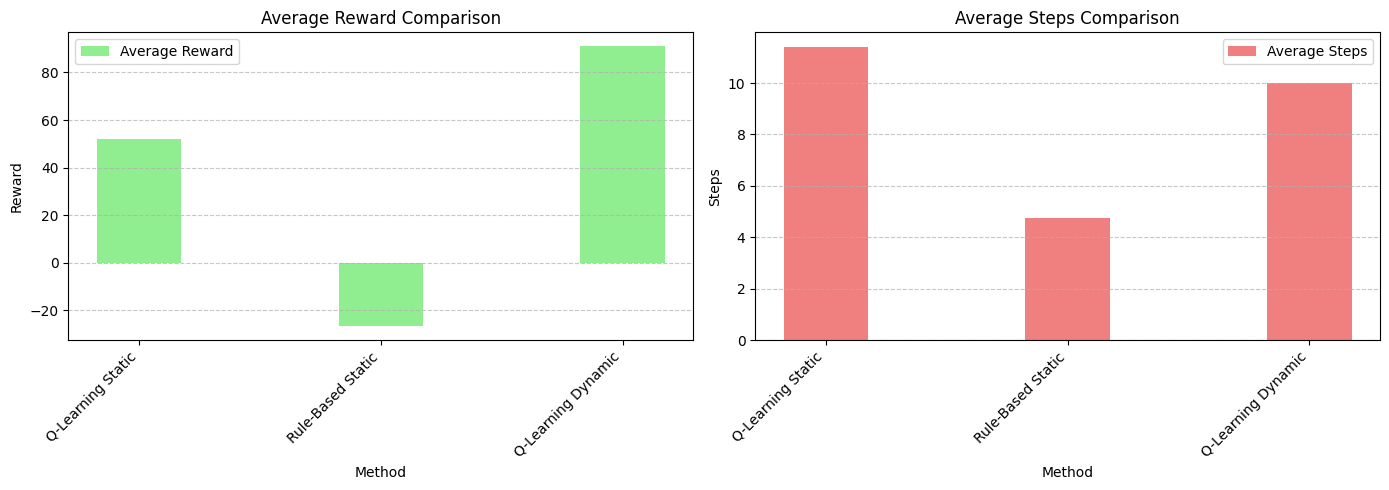

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Average Reward
bar_width = 0.35
index = np.arange(len(df['Method']))

axes[0].bar(index, df['Average Reward'], bar_width, label='Average Reward', color='lightgreen')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Reward')
axes[0].set_title('Average Reward Comparison')
axes[0].set_xticks(index)
axes[0].set_xticklabels(df['Method'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Average Steps
axes[1].bar(index, df['Average Steps'], bar_width, label='Average Steps', color='lightcoral')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Steps')
axes[1].set_title('Average Steps Comparison')
axes[1].set_xticks(index)
axes[1].set_xticklabels(df['Method'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()